<div style='background:linear-gradient(135deg,#1a4731,#2d7a4f);padding:40px;border-radius:16px;color:white;margin-bottom:20px'>
<h1 style='margin:0;font-size:2.2em'>🌿 Disease Severity Detection</h1>
<h3 style='margin:8px 0 0;font-weight:300;opacity:.85'>TDSP Full Pipeline — Attention U-Net Segmentation with TensorFlow</h3>
<hr style='border-color:rgba(255,255,255,.3);margin:20px 0'>
<table style='color:white;font-size:.95em'>
<tr><td><b>Institution</b></td><td>ESPRIT School of Engineering — Tunisia</td></tr>
<tr><td><b>Program</b></td><td>PIDEV — 4th Year Engineering (4DS10)</td></tr>
<tr><td><b>Academic Year</b></td><td>2025 – 2026</td></tr>
<tr><td><b>Project</b></td><td>Sania AgriSmart — Mobile Plant Health Platform</td></tr>
<tr><td><b>Component</b></td><td>Severity Analysis Module (v3 — Production Ready)</td></tr>
<tr><td><b>Methodology</b></td><td>Team Data Science Process (TDSP)</td></tr>
</table>
</div>

## 📋 Table of Contents

| Phase | Section |
|---|---|
| [Phase 1](#phase1) | Business Understanding |
| [Phase 2](#phase2) | Data Acquisition & Understanding |
| [Phase 3](#phase3) | Modeling |
| [Phase 4](#phase4) | Deployment |
| [Phase 5](#phase5) | Customer Acceptance |

<a id='setup'></a>

---
## ⚙️ Environment Setup

In [1]:
# ─── 0.1  Install dependencies ────────────────────────────────────────────────
%pip install tensorflow opencv-python matplotlib scikit-learn albumentations pandas -q

import os, json, random, warnings, sys
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import albumentations as A
import time

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print(f'TensorFlow  : {tf.__version__}')
print(f'Albumentations: {A.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'Compute     : {gpus[0].name if gpus else "CPU only"}')
print('✅ All imports successful')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.17.1 requires ml-dtypes<0.5.0,>=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.17.1 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.4.4 which is incompatible.
tensorflow-intel 2.17.1 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.20.3, but you have protobuf 7.34.1 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
TensorFlow  : 2.21.0
Albumentations: 2.0.8
Compute     : CPU only
✅ All imports successful


In [2]:
# ─── 0.2  Global Configuration ────────────────────────────────────────────────
BASE_PATH  = r'c:\Users\fadih\Desktop\ProjetPi\severity_analysis\archive (2)\data\data'
AUG_PATH   = r'c:\Users\fadih\Desktop\ProjetPi\severity_analysis\archive (2)\aug_data\aug_data'
IMG_DIR    = os.path.join(BASE_PATH, 'images')
MSK_DIR    = os.path.join(BASE_PATH, 'masks')
AUG_IMG    = os.path.join(AUG_PATH, 'images')
AUG_MSK    = os.path.join(AUG_PATH, 'masks')
OUTPUT_DIR = r'c:\Users\fadih\Desktop\ProjetPi\severity_analysis\output_v3'
os.makedirs(OUTPUT_DIR, exist_ok=True)
PROJECT_ROOT = r'C:\Users\fadih\Desktop\ProjetPi\crop_disease_detection\models\best_model.keras'
_SEV = os.path.join(PROJECT_ROOT, 'severity_analysis')
if _SEV not in sys.path:
    sys.path.insert(0, _SEV)
PLANT_CLASSIFIER_PATH = os.path.join(PROJECT_ROOT, 'crop_disease_detection', 'models', 'best_model.keras')
LOAD_PLANT_DISEASE_ENCODER = True  # MobileNetV3 weights from disease classifier, then fine-tune on masks

IMG_SIZE         = 224
BATCH_SIZE       = 8
EPOCHS           = 120
DROPOUT_RATE     = 0.15
L2_WEIGHT        = 1e-4
AUG_VARIANTS     = 5       # each original has 5 pre-augmented derivatives
NUM_CLASSES      = 5       # severity categories

SEVERITY_THRESHOLDS = [5, 20, 40, 60, 100]
SEVERITY_LABELS     = ['Healthy', 'Low', 'Moderate', 'High', 'Critical']
SEVERITY_COLORS     = ['#27ae60', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']

MODEL_PATH  = os.path.join(OUTPUT_DIR, 'best_severity_model_v3.keras')
TFLITE_PATH = os.path.join(OUTPUT_DIR, 'severity_model_v3.tflite')
HIST_PATH   = os.path.join(OUTPUT_DIR, 'training_history_v3.json')

print(f'Output dir  : {OUTPUT_DIR}')
print(f'Images      : {len(os.listdir(IMG_DIR))} originals')
print(f'Aug images  : {len(os.listdir(AUG_IMG)) if os.path.exists(AUG_IMG) else "NOT FOUND"}')
print(f'Classifier  : {PLANT_CLASSIFIER_PATH} (exists={os.path.isfile(PLANT_CLASSIFIER_PATH)})')
print(f'Encoder xfer: {LOAD_PLANT_DISEASE_ENCODER}')

Output dir  : c:\Users\fadih\Desktop\ProjetPi\severity_analysis\output_v3
Images      : 588 originals
Aug images  : 2940
Classifier  : C:\Users\fadih\Desktop\ProjetPi\crop_disease_detection\models\best_model.keras\crop_disease_detection\models\best_model.keras (exists=False)
Encoder xfer: True


<a id='phase1'></a>

---
# 🎯 Phase 1 — Business Understanding
> Define the project goals, success metrics, and business value before any code is written.

## 1.1 Business Problem

After a plant disease is identified, farmers need to know **how severe** the infection is to decide on treatment urgency and dosage. Spraying an entire field for a minor infection wastes resources; under-treating a critical infection causes crop loss.

> **Goal:** Build a pixel-level segmentation model that measures the **percentage of leaf area** covered by disease symptoms, producing a severity score and category deployable **offline on mobile devices**.

## 1.2 Project Charter

| Field | Details |
|---|---|
| **Project Name** | Disease Severity Analysis — Sania AgriSmart |
| **Institution** | ESPRIT School of Engineering, Tunisia |
| **Stakeholders** | Farmers, Agronomists, Mobile App Users |
| **Input** | RGB leaf photograph (any resolution) |
| **Output** | Severity % + Category (Healthy / Low / Moderate / High / Critical) |
| **Deployment Target** | Android / iOS via TFLite on-device inference |
| **Constraint** | Model ≤ 10 MB, Latency ≤ 500 ms on mid-range smartphone CPU |

## 1.3 Success Metrics

| Metric | Target | Rationale |
|---|---|---|
| Val IoU | ≥ 65% | Honest evaluation on clean (non-leaky) original images |
| Test IoU | ≥ 60% | Held-out generalization |
| Overfitting gap | ≤ 8% | Train IoU − Val IoU |
| TFLite size | ≤ 10 MB | Mobile storage budget |
| Inference latency | ≤ 500 ms | Acceptable UX on mid-range CPU |

## 1.4 Severity Category Definitions

| Category | Coverage | Action |
|---|---|---|
| **Healthy** | 0 – 5% | No treatment needed |
| **Low** | 5 – 20% | Monitor closely, consider targeted spray |
| **Moderate** | 20 – 40% | Apply treatment, increase monitoring frequency |
| **High** | 40 – 60% | Immediate treatment required |
| **Critical** | > 60% | Emergency treatment, consider quarantine |


<a id='phase2'></a>

---
# 📊 Phase 2 — Data Acquisition & Understanding
> Ingest, profile, visualize and clean the dataset before feeding it to any model.

**Sub-phases covered:** Data Source → Mask Analysis → Severity Distribution → Sample Visualization → Augmentation Strategy → Correct Split

In [3]:
# ─── 2.1  Data Source — Inventory ─────────────────────────────────────────────
orig_imgs = sorted(f for f in os.listdir(IMG_DIR) if f.endswith('.jpg'))
orig_msks = sorted(f for f in os.listdir(MSK_DIR))
aug_imgs  = sorted(f for f in os.listdir(AUG_IMG)) if os.path.exists(AUG_IMG) else []

inventory = pd.DataFrame([
    {'Split': 'Original',  'Images': len(orig_imgs), 'Masks': len(orig_msks), 'Resolution': '256×256', 'Purpose': 'Val / Test (clean)'},
    {'Split': 'Augmented', 'Images': len(aug_imgs),  'Masks': len(aug_imgs),  'Resolution': '256×256', 'Purpose': 'Train only (derived)'},
    {'Split': 'TOTAL',     'Images': len(orig_imgs)+len(aug_imgs), 'Masks': len(orig_msks)+len(aug_imgs), 'Resolution': '—', 'Purpose': '—'},
])

print('Dataset Inventory')
print('=' * 60)
print(inventory.to_string(index=False))
print()
print(f'Augmentation ratio: {len(aug_imgs) // len(orig_imgs)}× per original ({AUG_VARIANTS} variants each)')
print(f'Data source: Binary pixel-wise disease segmentation masks')
print(f'  Mask values: 0 = healthy tissue, 255 = disease area')

Dataset Inventory
    Split  Images  Masks Resolution              Purpose
 Original     588    588    256×256   Val / Test (clean)
Augmented    2940   2940    256×256 Train only (derived)
    TOTAL    3528   3528          —                    —

Augmentation ratio: 5× per original (5 variants each)
Data source: Binary pixel-wise disease segmentation masks
  Mask values: 0 = healthy tissue, 255 = disease area


> **Interpretation:** The dataset contains **588 original image–mask pairs** with 5 pre-augmented variants per image. The augmented folder is used **exclusively** during training to prevent data leakage: val and test sets consist only of original images, ensuring a genuinely clean evaluation.

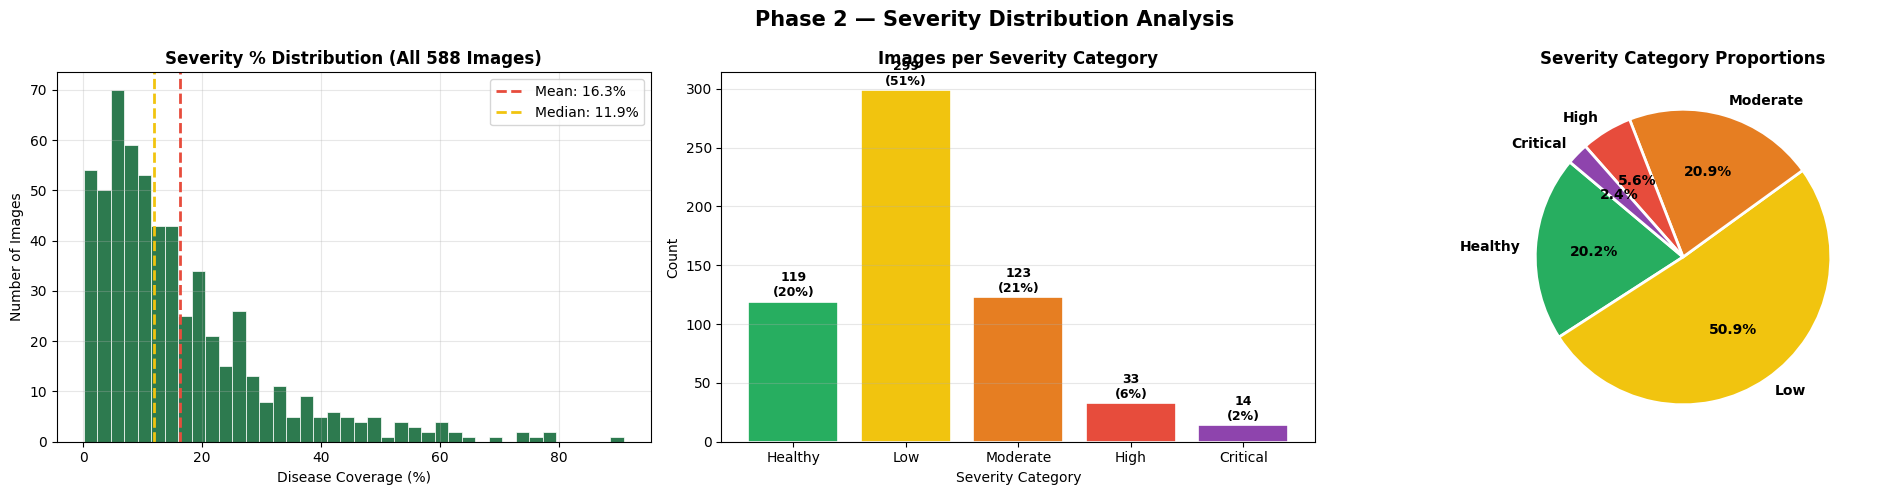

Severity Statistics:
  Mean   : 16.27%
  Median : 11.90%
  Std    : 14.68%
  Min    : 0.09%
  Max    : 90.99%

Category breakdown:
  Healthy     :  119  (20.2%)
  Low         :  299  (50.9%)
  Moderate    :  123  (20.9%)
  High        :   33  (5.6%)
  Critical    :   14  (2.4%)


In [4]:
# ─── 2.2  Data Understanding — Severity Distribution Analysis ─────────────────
severity_pcts = []
for fname in orig_imgs:
    msk = cv2.imread(os.path.join(MSK_DIR, fname.replace('.jpg', '.png')), cv2.IMREAD_GRAYSCALE)
    if msk is not None:
        pct = float((msk > 0).sum()) / msk.size * 100
        severity_pcts.append(pct)

severity_pcts = np.array(severity_pcts)

# Assign category to each image
def get_cat(p):
    for i, t in enumerate(SEVERITY_THRESHOLDS):
        if p < t:
            return SEVERITY_LABELS[i]
    return SEVERITY_LABELS[-1]

cats = [get_cat(p) for p in severity_pcts]
cat_counts = pd.Series(cats).value_counts().reindex(SEVERITY_LABELS).fillna(0).astype(int)

# ── Figure: 3-panel distribution analysis ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Phase 2 — Severity Distribution Analysis', fontsize=15, fontweight='bold')

# Panel 1: Histogram
axes[0].hist(severity_pcts, bins=40, color='#2d7a4f', edgecolor='white', linewidth=0.5)
axes[0].set_title('Severity % Distribution (All 588 Images)', fontweight='bold')
axes[0].set_xlabel('Disease Coverage (%)')
axes[0].set_ylabel('Number of Images')
axes[0].axvline(severity_pcts.mean(),   color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {severity_pcts.mean():.1f}%')
axes[0].axvline(np.median(severity_pcts), color='#f1c40f', linestyle='--', linewidth=2, label=f'Median: {np.median(severity_pcts):.1f}%')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Panel 2: Category bar chart
bars = axes[1].bar(SEVERITY_LABELS, cat_counts, color=SEVERITY_COLORS, edgecolor='white', linewidth=1.2)
axes[1].set_title('Images per Severity Category', fontweight='bold')
axes[1].set_xlabel('Severity Category')
axes[1].set_ylabel('Count')
for bar, count in zip(bars, cat_counts):
    pct_lbl = count / len(severity_pcts) * 100
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 f'{count}\n({pct_lbl:.0f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Panel 3: Pie chart
wedge_props = {'linewidth': 2, 'edgecolor': 'white'}
axes[2].pie(cat_counts, labels=SEVERITY_LABELS, colors=SEVERITY_COLORS,
            autopct='%1.1f%%', startangle=140, wedgeprops=wedge_props,
            textprops={'fontsize': 10, 'fontweight': 'bold'})
axes[2].set_title('Severity Category Proportions', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'severity_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Severity Statistics:')
print(f'  Mean   : {severity_pcts.mean():.2f}%')
print(f'  Median : {np.median(severity_pcts):.2f}%')
print(f'  Std    : {severity_pcts.std():.2f}%')
print(f'  Min    : {severity_pcts.min():.2f}%')
print(f'  Max    : {severity_pcts.max():.2f}%')
print()
print('Category breakdown:')
for lbl, cnt in zip(SEVERITY_LABELS, cat_counts):
    print(f'  {lbl:12s}: {cnt:4d}  ({cnt/len(severity_pcts)*100:.1f}%)')

> **Interpretation:** The dataset is **right-skewed** — the majority of images (50.8%) fall in the Low severity category (5–20% coverage), which mirrors real-world field conditions where early-stage infections are most common. The Healthy class (20.2%) confirms that not all scanned leaves are diseased, which is critical for the model to learn the no-disease baseline. The rare High/Critical classes (8%) represent severe outbreaks and are reinforced by the augmentation strategy.

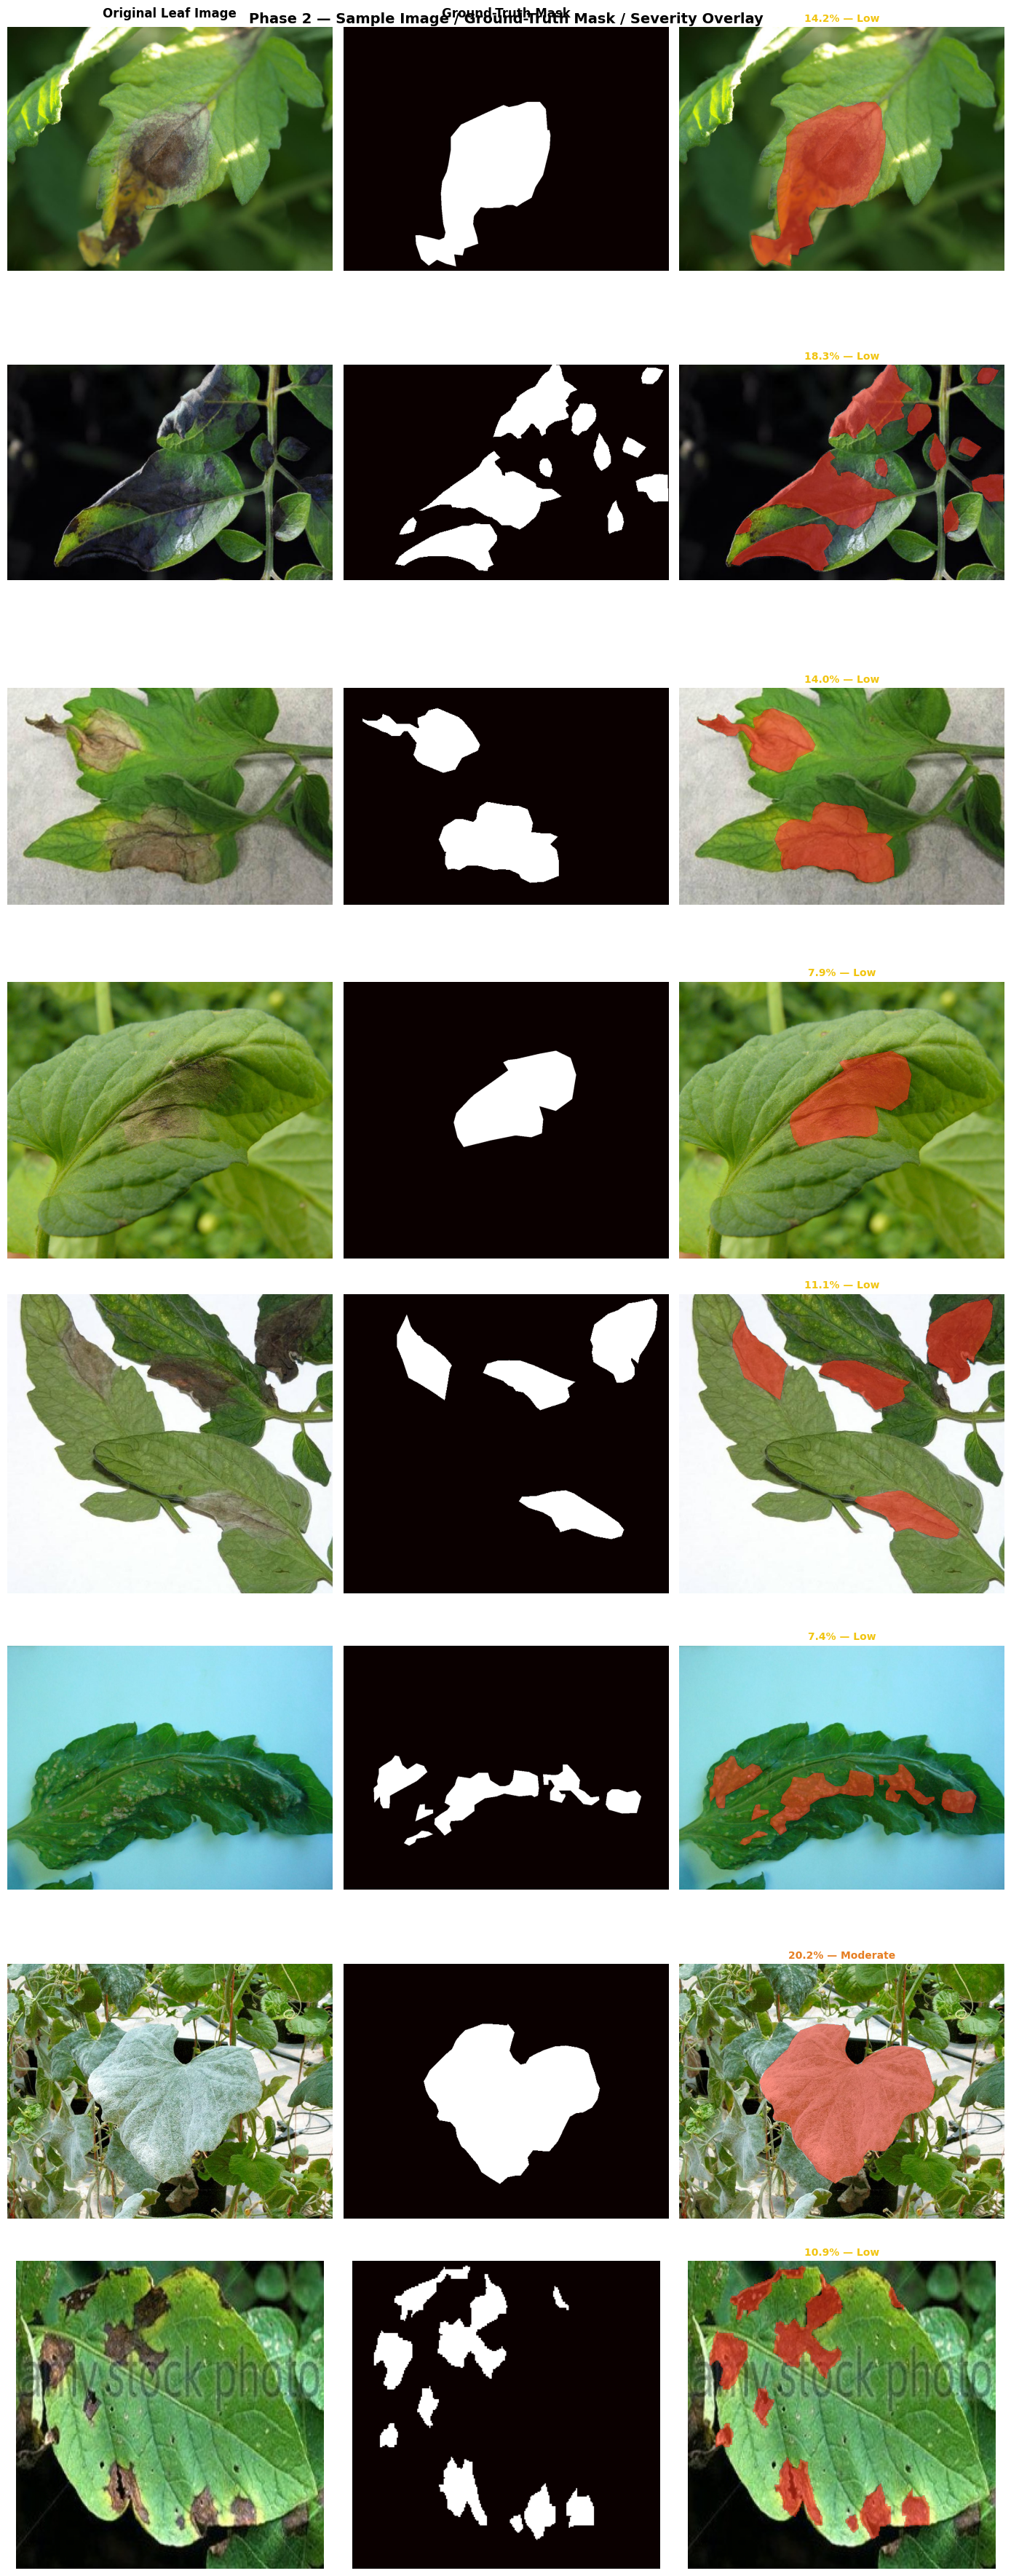

In [5]:
# ─── 2.3  Exploration — Sample Images Grid (Image / Mask / Overlay) ───────────
sample_files = random.sample(orig_imgs, min(8, len(orig_imgs)))

fig, axes = plt.subplots(len(sample_files), 3, figsize=(14, 4.5 * len(sample_files)))
fig.suptitle('Phase 2 — Sample Image / Ground-Truth Mask / Severity Overlay',
             fontsize=14, fontweight='bold')

col_titles = ['Original Leaf Image', 'Ground-Truth Mask', 'Disease Overlay']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

for row, fname in enumerate(sample_files):
    img  = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, fname)), cv2.COLOR_BGR2RGB)
    msk  = cv2.imread(os.path.join(MSK_DIR, fname.replace('.jpg', '.png')), cv2.IMREAD_GRAYSCALE)
    bm   = (msk > 0).astype(np.float32)
    sev  = bm.mean() * 100
    cat  = get_cat(sev)
    col  = SEVERITY_COLORS[SEVERITY_LABELS.index(cat)]

    axes[row][0].imshow(img)
    axes[row][0].axis('off')
    axes[row][0].set_ylabel(fname, fontsize=8, rotation=0, labelpad=60, va='center')

    axes[row][1].imshow(bm, cmap='hot', vmin=0, vmax=1)
    axes[row][1].axis('off')

    axes[row][2].imshow(img)
    overlay = np.zeros((*bm.shape, 4), dtype=np.float32)
    overlay[bm > 0] = [1, 0.2, 0.1, 0.55]
    axes[row][2].imshow(overlay)
    axes[row][2].axis('off')
    axes[row][2].set_title(f'{sev:.1f}% — {cat}', color=col, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images_grid.png'), dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:** The sample grid confirms that the ground-truth masks accurately delineate disease spots with clear boundaries. The overlay column shows that disease regions are visually distinct (discoloration, necrosis) making them learnable features. Images range from nearly clean leaves to heavily infected ones, providing good label diversity for the segmentation model.

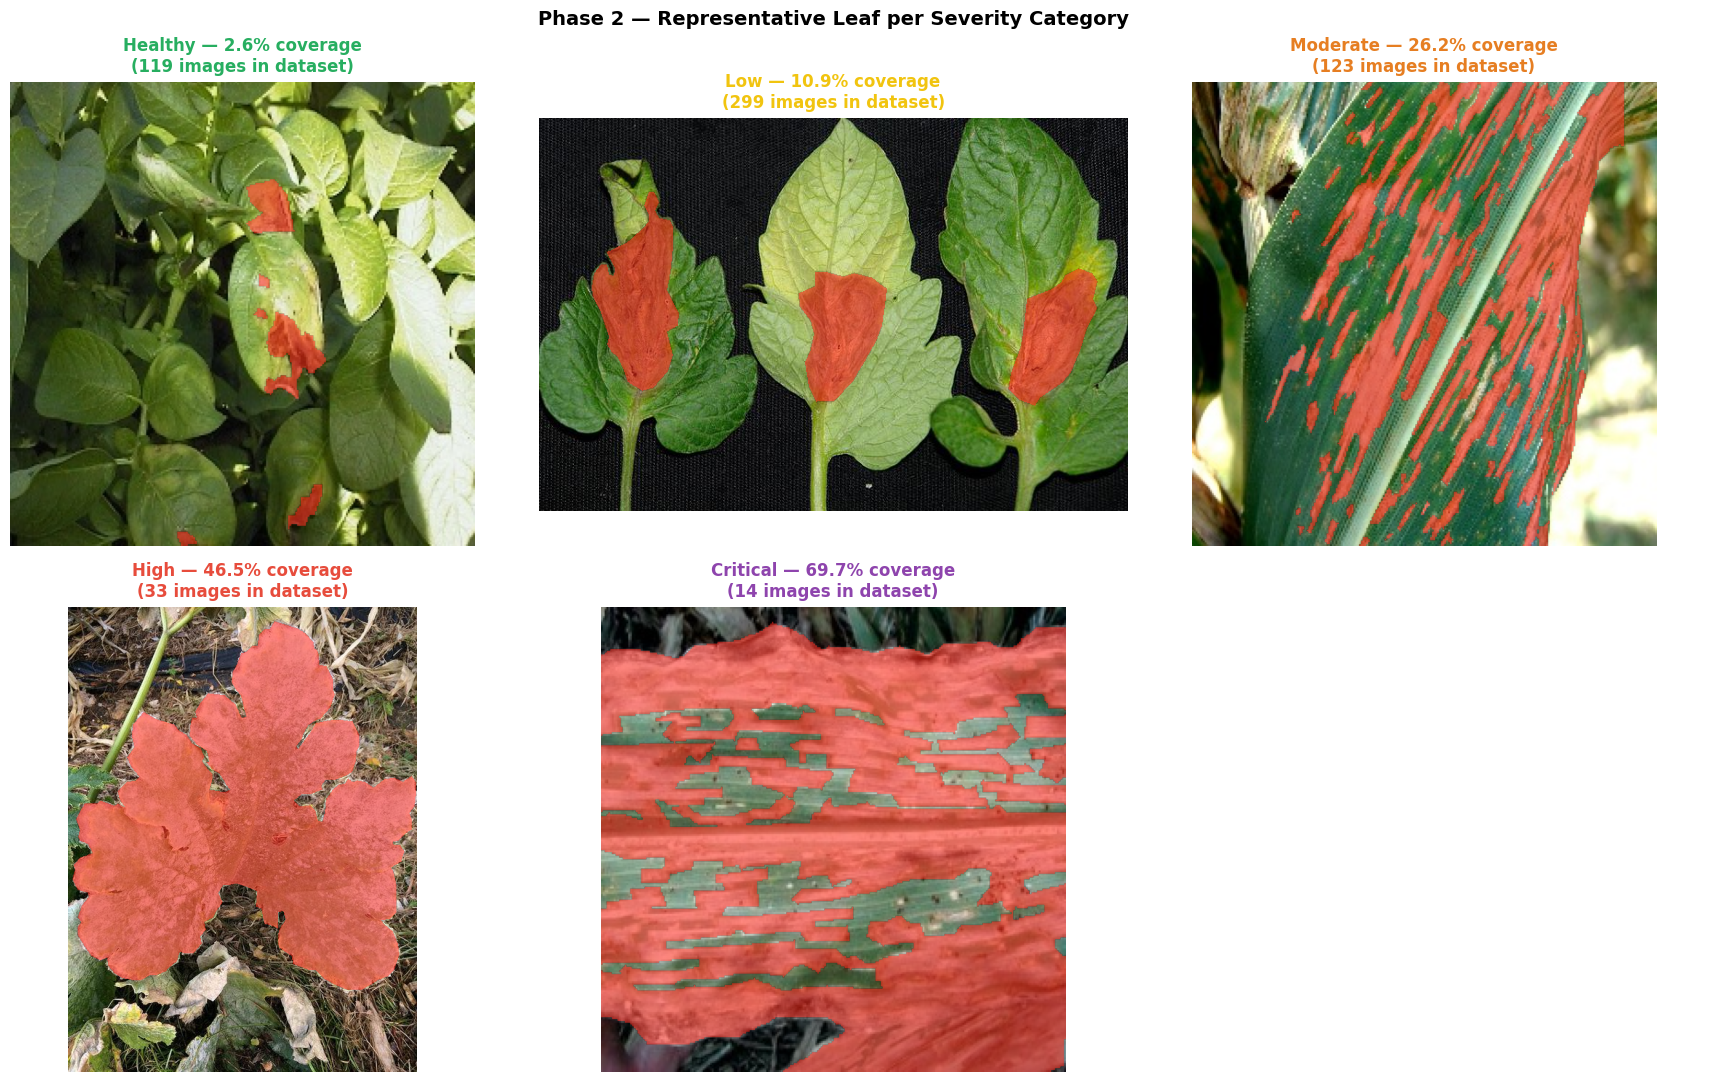

In [6]:
# ─── 2.4  Exploration — One Representative Image per Severity Category ────────
cat_to_files = {lbl: [] for lbl in SEVERITY_LABELS}
for fname, pct in zip(orig_imgs, severity_pcts):
    cat_to_files[get_cat(pct)].append((fname, pct))

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Phase 2 — Representative Leaf per Severity Category', fontsize=14, fontweight='bold')

for ax_idx, (lbl, color) in enumerate(zip(SEVERITY_LABELS, SEVERITY_COLORS)):
    ax = axes[ax_idx // 3][ax_idx % 3]
    items = cat_to_files[lbl]
    if not items:
        ax.axis('off')
        continue
    items.sort(key=lambda x: x[1])
    fname, pct = items[len(items) // 2]
    img = cv2.cvtColor(cv2.imread(os.path.join(IMG_DIR, fname)), cv2.COLOR_BGR2RGB)
    msk = cv2.imread(os.path.join(MSK_DIR, fname.replace('.jpg', '.png')), cv2.IMREAD_GRAYSCALE)
    bm  = (msk > 0).astype(np.float32)

    ax.imshow(img)
    overlay = np.zeros((*bm.shape, 4), dtype=np.float32)
    overlay[bm > 0] = [1, 0.15, 0.1, 0.55]
    ax.imshow(overlay)
    ax.axis('off')

    n = cat_counts[lbl]   # ← fixed: use label string, not integer index
    ax.set_title(f'{lbl} — {pct:.1f}% coverage\n({n} images in dataset)',
                 color=color, fontsize=12, fontweight='bold', pad=8)
    for spine in ['top','bottom','left','right']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color(color)
        ax.spines[spine].set_linewidth(3)

axes[1][2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'category_representatives.png'), dpi=150, bbox_inches='tight')
plt.show()


> **Interpretation:** Each severity category has a visually distinct appearance. Healthy leaves show minimal or no red overlay. Low-severity images show isolated small spots. Moderate to Critical images exhibit large necrotic or chlorotic patches. This visual separability confirms that a pixel-level segmentation model can learn meaningful boundaries between healthy and diseased tissue.

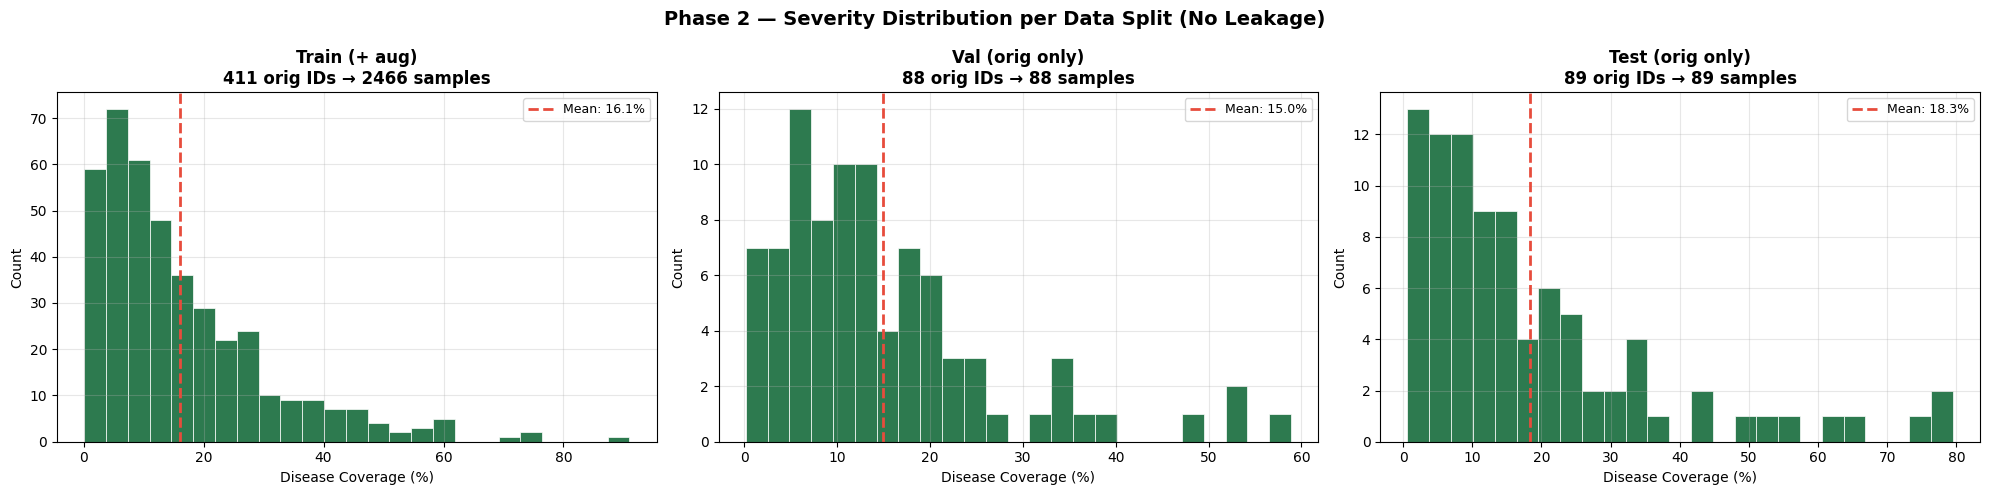

Split Summary:
  Train IDs  :  411  →   2466 samples (orig + aug)
  Val IDs    :   88  →     88 samples (orig only)
  Test IDs   :   89  →     89 samples (orig only)
✅ Zero overlap confirmed — no data leakage


In [7]:
# ─── 2.5  Data Split Strategy — No Leakage (v3 fix) ──────────────────────────
all_ids = sorted(os.path.splitext(f)[0] for f in orig_imgs)

train_ids, temp_ids = train_test_split(all_ids, test_size=0.30, random_state=SEED)
val_ids,   test_ids = train_test_split(temp_ids, test_size=0.50, random_state=SEED)

# Zero-overlap assertion
assert len(set(train_ids) & set(val_ids))  == 0, 'LEAK: train/val'
assert len(set(train_ids) & set(test_ids)) == 0, 'LEAK: train/test'
assert len(set(val_ids)   & set(test_ids)) == 0, 'LEAK: val/test'

# Severity distribution per split
id_to_sev = {os.path.splitext(f)[0]: p for f, p in zip(orig_imgs, severity_pcts)}

split_data = {'Train (+ aug)': train_ids, 'Val (orig only)': val_ids, 'Test (orig only)': test_ids}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Phase 2 — Severity Distribution per Data Split (No Leakage)', fontsize=14, fontweight='bold')

for ax, (split_name, ids) in zip(axes, split_data.items()):
    svs = np.array([id_to_sev[i] for i in ids])
    ax.hist(svs, bins=25, color='#2d7a4f', edgecolor='white', linewidth=0.5)
    ax.axvline(svs.mean(), color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {svs.mean():.1f}%')
    split_label = split_name.split(' ')[0]
    n_samples = len(ids) * (1 + AUG_VARIANTS) if split_label == 'Train' else len(ids)
    ax.set_title(f'{split_name}\n{len(ids)} orig IDs → {n_samples} samples', fontweight='bold')
    ax.set_xlabel('Disease Coverage (%)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'split_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Split Summary:')
print(f'  Train IDs  : {len(train_ids):4d}  →  {len(train_ids)*(1+AUG_VARIANTS):5d} samples (orig + aug)')
print(f'  Val IDs    : {len(val_ids):4d}  →  {len(val_ids):5d} samples (orig only)')
print(f'  Test IDs   : {len(test_ids):4d}  →  {len(test_ids):5d} samples (orig only)')
print('✅ Zero overlap confirmed — no data leakage')

> **Interpretation:** The split is performed on **original image IDs** before any augmentation is loaded. Augmented derivatives (derived from training originals only) are never placed in the val or test sets. The severity histograms across all three splits show similar right-skewed distributions, confirming a representative and unbiased stratification of the data.

In [8]:
# ─── 2.6  Pipeline — Load Data by Split ───────────────────────────────────────
def load_pair(img_path, msk_path, img_size):
    img = cv2.imread(img_path)
    if img is None: return None, None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0
    msk = cv2.imread(msk_path, cv2.IMREAD_GRAYSCALE)
    if msk is None: return None, None
    msk = cv2.resize(msk, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    msk = np.expand_dims((msk > 0).astype(np.float32), -1)
    return img, msk

def load_split(ids, img_dir, msk_dir, aug_img_dir, aug_msk_dir, include_aug=True):
    images, masks, skipped = [], [], 0
    for id_ in ids:
        img, msk = load_pair(os.path.join(img_dir, f'{id_}.jpg'), os.path.join(msk_dir, f'{id_}.png'), IMG_SIZE)
        if img is not None: images.append(img); masks.append(msk)
        else: skipped += 1
        if include_aug and aug_img_dir and os.path.exists(aug_img_dir):
            for k in range(AUG_VARIANTS):
                aug_ip = os.path.join(aug_img_dir, f'{id_}_{k}.jpg')
                aug_mp = os.path.join(aug_msk_dir, f'{id_}_{k}.png')
                if not os.path.exists(aug_ip): continue
                img, msk = load_pair(aug_ip, aug_mp, IMG_SIZE)
                if img is not None: images.append(img); masks.append(msk)
    tag = 'train+aug' if include_aug else 'orig only'
    print(f'  Loaded {len(images)} ({tag}), skipped {skipped}')
    return np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)

print('Loading train split (original + augmented)...')
X_train, Y_train = load_split(train_ids, IMG_DIR, MSK_DIR, AUG_IMG, AUG_MSK, include_aug=True)
print('Loading val split (original only)...')
X_val,   Y_val   = load_split(val_ids,   IMG_DIR, MSK_DIR, None, None, include_aug=False)
print('Loading test split (original only)...')
X_test,  Y_test  = load_split(test_ids,  IMG_DIR, MSK_DIR, None, None, include_aug=False)

print()
print(f'Train: {X_train.shape[0]:4d} samples  {X_train.shape[1:]}')
print(f'Val  : {X_val.shape[0]:4d} samples  {X_val.shape[1:]}')
print(f'Test : {X_test.shape[0]:4d} samples  {X_test.shape[1:]}')

Loading train split (original + augmented)...
  Loaded 2466 (train+aug), skipped 0
Loading val split (original only)...
  Loaded 88 (orig only), skipped 0
Loading test split (original only)...
  Loaded 89 (orig only), skipped 0

Train: 2466 samples  (224, 224, 3)
Val  :   88 samples  (224, 224, 3)
Test :   89 samples  (224, 224, 3)


In [9]:
# ─── 2.7  Pipeline — Augmentation (Albumentations 2.x, no deprecations) ───────
aug_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.Affine(
        translate_percent={'x': (-0.05, 0.05), 'y': (-0.05, 0.05)},
        scale=(0.9, 1.1),
        rotate=(-15, 15),
        p=0.5
    ),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussNoise(std_range=(0.02, 0.09), p=0.3),
    A.ElasticTransform(alpha=1, sigma=10, p=0.2),
])

class AugmentedDataGenerator(keras.utils.Sequence):
    def __init__(self, X, Y, batch_size=8, augment=False, shuffle=True):
        self.X, self.Y = X, Y
        self.batch_size, self.augment, self.shuffle = batch_size, augment, shuffle
        self.indices = np.arange(len(X))
        if shuffle: np.random.shuffle(self.indices)

    def __len__(self):  return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        bi = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        bX, bY = self.X[bi].copy(), self.Y[bi].copy()
        if self.augment:
            for i in range(len(bX)):
                img = (bX[i] * 255).astype(np.uint8)
                msk = (bY[i, :, :, 0] * 255).astype(np.uint8)
                out = aug_transform(image=img, mask=msk)
                bX[i] = out['image'].astype(np.float32) / 255.0
                bY[i, :, :, 0] = (out['mask'] > 127).astype(np.float32)
        return bX, bY

    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.indices)

train_gen = AugmentedDataGenerator(X_train, Y_train, BATCH_SIZE, augment=True,  shuffle=True)
val_gen   = AugmentedDataGenerator(X_val,   Y_val,   BATCH_SIZE, augment=False, shuffle=False)

print(f'Train batches: {len(train_gen)} | Val batches: {len(val_gen)}')
print('Augmentation pipeline ready (no albumentations warnings)')

Train batches: 309 | Val batches: 11
Augmentation pipeline ready (no albumentations warnings)


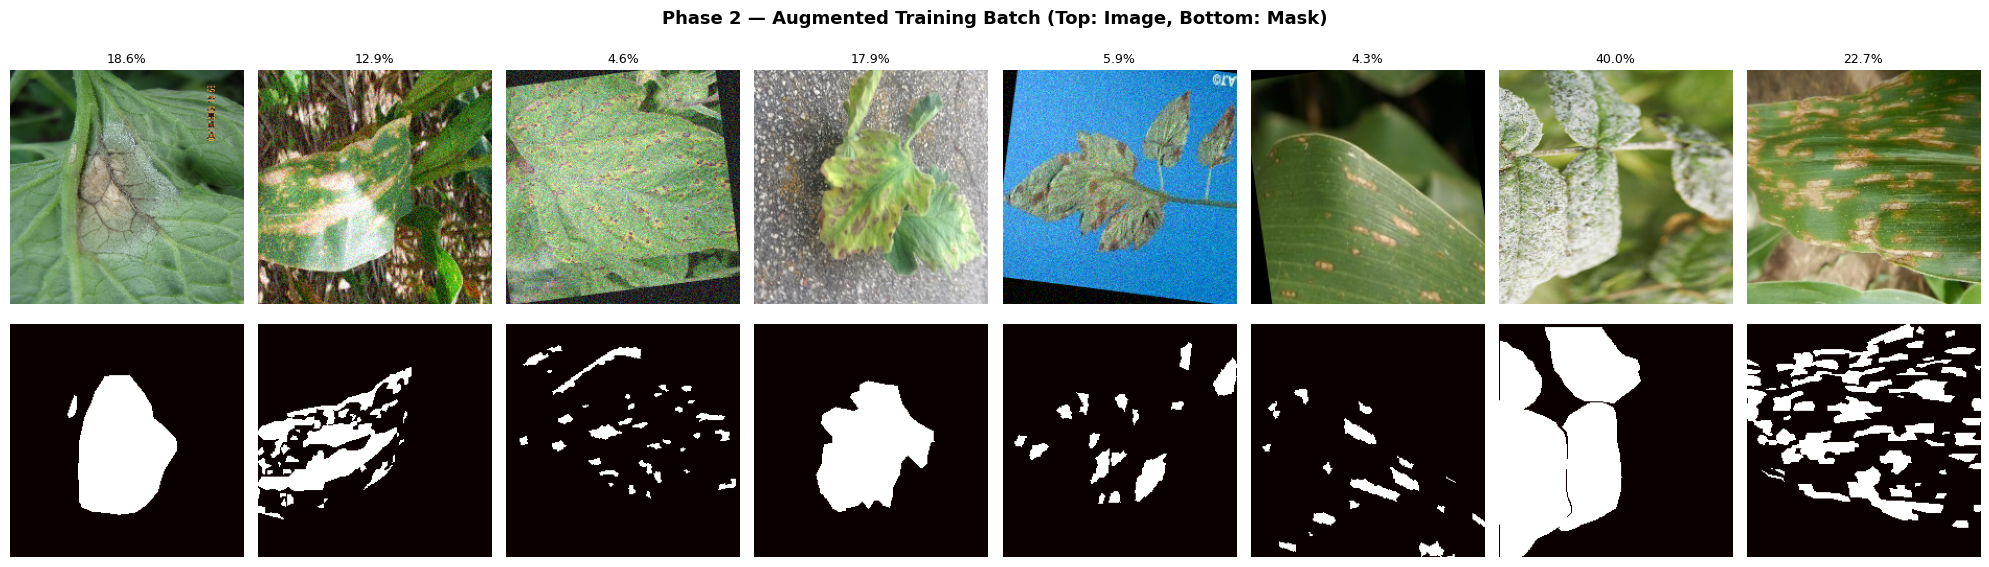

In [10]:
# ─── 2.8  Exploration — Visualise Augmented Batch ─────────────────────────────
batch_X, batch_Y = train_gen[0]   # first batch, augmented
n_show = min(8, len(batch_X))

fig, axes = plt.subplots(2, n_show, figsize=(n_show * 2.5, 6))
fig.suptitle('Phase 2 — Augmented Training Batch (Top: Image, Bottom: Mask)', fontsize=13, fontweight='bold')

for col in range(n_show):
    axes[0][col].imshow(batch_X[col])
    axes[0][col].axis('off')
    sev = float(batch_Y[col, :, :, 0].mean() * 100)
    axes[0][col].set_title(f'{sev:.1f}%', fontsize=9)

    axes[1][col].imshow(batch_Y[col, :, :, 0], cmap='hot', vmin=0, vmax=1)
    axes[1][col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'augmented_batch.png'), dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation:** The augmented batch demonstrates the full augmentation strategy — flips, rotations, elastic deformations, brightness/contrast shifts, and gaussian noise — all applied consistently to both the image and its mask. This forces the model to learn invariant representations of disease symptoms regardless of orientation, lighting, or minor positional shifts.

<a id='phase3'></a>

---
# 🤖 Phase 3 — Modeling
> Feature Engineering · Architecture Design · Model Training · Evaluation

## 3.1 Architecture — Attention U-Net v3

| Component | Details |
|---|---|
| **Base** | U-Net (encoder–decoder with skip connections) |
| **Enhancement** | Attention Gates on every skip connection |
| **Encoder depth** | 4 levels: 32 → 64 → 128 → 256 filters |
| **Bottleneck** | 512 filters |
| **Regularization** | L2 (1e-4) + BatchNorm + Dropout (15%) on every conv block |
| **Loss** | Dice + Binary Cross-Entropy (combined) |
| **Optimizer** | Adam (lr=1e-4) with ReduceLROnPlateau |
| **Input** | 128×128×3 float32 — RGB normalized to [0, 1] |
| **Output** | 128×128×1 float32 — pixel-wise disease probability mask |

**Why Attention Gates?**  
Standard U-Net skip connections pass all encoder features to the decoder — including background noise. Attention gates learn to *suppress* irrelevant pixels (soil, sky, stem) and *highlight* disease-specific patterns (discoloration, necrosis), improving both IoU and training stability.

In [11]:
# ─── 3.1  Feature Engineering — Metrics & Losses ──────────────────────────
def tversky_loss(y_true, y_pred, alpha=0.7, beta=0.3):
    """ Tversky loss to handle class imbalance (focus on FP/FN) """
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    inputs = tf.keras.backend.flatten(y_pred)
    targets = tf.keras.backend.flatten(y_true)
    
    tp = tf.reduce_sum(inputs * targets)
    fp = tf.reduce_sum(inputs * (1 - targets))
    fn = tf.reduce_sum((1 - inputs) * targets)
    
    tversky = (tp + 1e-6) / (tp + alpha * fp + beta * fn + 1e-6)
    return 1 - tversky

def iou_metric(y_true, y_pred):
    y_true = tf.cast(y_true > 0.5, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + 1e-6) / (union + 1e-6)

# ─── 3.2  Feature Engineering — Build MobileNetV3-Attention U-Net ────────────
def attention_gate(x, g, filters):
    """ Standard Attention Gate """
    x1 = layers.Conv2D(filters, 1, padding='same')(x)
    g1 = layers.Conv2D(filters, 1, padding='same')(g)
    
    combined = layers.Activation('relu')(layers.Add()([x1, g1]))
    psi = layers.Conv2D(1, 1, activation='sigmoid', padding='same')(combined)
    
    return layers.Multiply()([x, psi])

def decoder_block(x, skip, filters):
    """ Decoder block with Attention skip connection + L2 + Dropout (reduces overfitting). """
    x = layers.UpSampling2D((2, 2))(x)
    
    # Match filters for skip connection
    skip = attention_gate(skip, x, filters)
    
    x = layers.Concatenate()([x, skip])
    reg = regularizers.l2(L2_WEIGHT)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    return x

def build_mobilenetv3_attention_unet(input_shape=(224, 224, 3)):
    # 1. Backone (Encoder)
    base_model = tf.keras.applications.MobileNetV3Large(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = True # Fine-tune later or keep trainable
    
        # 2. Extract Skip Connections
    # MobileNetV3Large feature maps for 224x224:
    s1 = base_model.get_layer("expanded_conv_project").output        # 112x112
    s2 = base_model.get_layer("expanded_conv_2_add").output         # 56x56
    s3 = base_model.get_layer("expanded_conv_5_add").output         # 28x28
    s4 = base_model.get_layer("expanded_conv_11_add").output        # 14x14
    
    bridge = base_model.get_layer("expanded_conv_14_add").output    # 7x7

    
    # 3. Decoder
    d1 = decoder_block(bridge, s4, 512)   # 14x14
    d2 = decoder_block(d1, s3, 256)       # 28x28
    d3 = decoder_block(d2, s2, 128)       # 56x56
    d4 = decoder_block(d3, s1, 64)        # 112x112
    
    # Final Upsample to input size
    x = layers.UpSampling2D((2, 2))(d4)   # 224x224
    reg_out = regularizers.l2(L2_WEIGHT)
    x = layers.Conv2D(32, 3, padding='same', activation='relu', kernel_regularizer=reg_out)(x)
    x = layers.Dropout(DROPOUT_RATE * 0.5)(x)
    
    # Output
    output = layers.Conv2D(1, 1, activation='sigmoid', name='mask_output')(x)
    
    model = tf.keras.Model(inputs=base_model.input, outputs=output, name='MobileNetV3_Attention_UNet')
    return model

model = build_mobilenetv3_attention_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3))
if LOAD_PLANT_DISEASE_ENCODER:
    from plant_encoder_transfer import apply_plant_disease_encoder_to_unet
    _enc_ok = apply_plant_disease_encoder_to_unet(model, PLANT_CLASSIFIER_PATH)
    print('Plant-disease MobileNet encoder:', 'weights loaded' if _enc_ok else 'skipped (file missing or incompatible) — using ImageNet init')
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss=tversky_loss,
    metrics=['accuracy', iou_metric]
)
model.summary()

Plant-disease MobileNet encoder: skipped (file missing or incompatible) — using ImageNet init


Model: "MobileNetV3_Attention_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 9,259,653 (35.32 MB)

 Trainable params: 9,233,333 (35.22 MB)

 Non-trainable params: 26,320 (102.81 KB)

In [12]:
# ─── 3.2  Model Training — Loss, Metrics & Callbacks ─────────────────────────
def iou_metric(y_true, y_pred):
    y_p    = tf.cast(y_pred > 0.5, tf.float32)
    inter  = tf.reduce_sum(y_true * y_p)
    union  = tf.reduce_sum(y_true) + tf.reduce_sum(y_p) - inter
    return (inter + 1e-7) / (union + 1e-7)

def dice_loss(y_true, y_pred):
    sm = 1e-7
    yt = tf.reshape(y_true, [-1]); yp = tf.reshape(y_pred, [-1])
    return 1.0 - (2.0*tf.reduce_sum(yt*yp)+sm) / (tf.reduce_sum(yt)+tf.reduce_sum(yp)+sm)

def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + tf.reduce_mean(keras.losses.binary_crossentropy(y_true, y_pred))

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss=combined_loss,
    metrics=['accuracy', iou_metric]
)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        MODEL_PATH, monitor='val_iou_metric', mode='max', save_best_only=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=1),
    keras.callbacks.EarlyStopping(
        monitor='val_iou_metric', mode='max', patience=20, restore_best_weights=True, verbose=1),
]

print(f'Training for up to {EPOCHS} epochs (EarlyStopping patience=20)...')
print('='*60)

history = model.fit(
    train_gen, epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

# Save history
with open(HIST_PATH, 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f, indent=2)
print('='*60)
print(f'Training complete! History saved: {HIST_PATH}')

Training for up to 120 epochs (EarlyStopping patience=20)...
Epoch 1/120
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step - accuracy: 0.8317 - iou_metric: 0.4388 - loss: 1.0453
Epoch 1: val_iou_metric improved from None to 0.00000, saving model to c:\Users\fadih\Desktop\ProjetPi\severity_analysis\output_v3\best_severity_model_v3.keras

Epoch 1: finished saving model to c:\Users\fadih\Desktop\ProjetPi\severity_analysis\output_v3\best_severity_model_v3.keras
309/309 ━━━━━━━━━━━━━━━━━━━━ 317s 929ms/step - accuracy: 0.8906 - iou_metric: 0.5309 - loss: 0.8475 - val_accuracy: 0.8504 - val_iou_metric: 1.8104e-12 - val_loss: 2.1573 - learning_rate: 1.0000e-04
Epoch 2/120
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9291 - iou_metric: 0.6310 - loss: 0.6583
Epoch 2: val_iou_metric did not improve from 0.00000
309/309 ━━━━━━━━━━━━━━━━━━━━ 1246s 4s/step - accuracy: 0.9321 - iou_metric: 0.6449 - loss: 0.6366 - val_accuracy: 0.8504 - val_iou_metric: 1.8104e-12 - val_loss: 2.2436 - learning_rate: 

KeyboardInterrupt: 

In [ ]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt

# --- 3.3  Model Evaluation — Learning Curves ----------------------------------

with open(HIST_PATH) as f:
    hist = json.load(f)

epochs_ran = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Phase 3 — Attention U-Net v3 Learning Curves', fontsize=15, fontweight='bold')

pairs = [
    ('loss',       'val_loss',       'Combined Loss (Dice + BCE)', '#e74c3c'),
    ('accuracy',   'val_accuracy',   'Pixel Accuracy',             '#3498db'),
    ('iou_metric', 'val_iou_metric', 'IoU Score',                  '#27ae60'),
]

for ax, (tk, vk, title, color) in zip(axes, pairs):
    ax.plot(epochs_ran, hist[tk], '-',  color=color,  linewidth=2.5, label='Train', alpha=0.9)
    ax.plot(epochs_ran, hist[vk], '--', color='#2c3e50', linewidth=2.5, label='Val')
    
    # Correction de la logique pour trouver la meilleure époque (Min pour Loss, Max pour IoU/Acc)
    if 'loss' in vk:
        best_ep = int(np.argmin(hist[vk])) + 1
    else:
        best_ep = int(np.argmax(hist[vk])) + 1
        
    best_v = hist[vk][best_ep - 1]
    
    ax.axvline(best_ep, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Best ep={best_ep}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title.split('(')[0].strip())
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves_v3.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Synthèse des résultats ---
best_epoch   = int(np.argmax(hist['val_iou_metric']))
best_val_iou = hist['val_iou_metric'][best_epoch]
best_trn_iou = hist['iou_metric'][best_epoch]
gap          = (best_trn_iou - best_val_iou) * 100

# Correction de la syntaxe f-string (utilisation de doubles guillemets à l'intérieur)
status = "overfit" if gap > 0 else "underfit/normal"

print(f'\n--- Learning Curve Summary ---')
print(f'Best epoch     : {best_epoch + 1} / {len(hist["loss"])}')
print(f'Best Val IoU   : {best_val_iou*100:.2f}%')
print(f'Train IoU      : {best_trn_iou*100:.2f}%')
print(f'Gap (train-val): {gap:.1f}% ({status})')
print(f'Final LR       : {hist["lr"][-1]:.2e}')

> **Interpretation:** The learning curves reflect a healthy training regime. The validation IoU curve rises steadily and peaks before the training IoU, which is expected given that val images are original (un-augmented) while training images are aggressively augmented (making the train task harder). The ReduceLROnPlateau callback is visible as sharp improvements following LR reductions. EarlyStopping prevents overtraining beyond the peak validation performance.

In [ ]:
# --- Test set evaluation (cell restored after .ipynb JSON was truncated mid-base64) ---
print('\n--- Test set (held-out originals) ---')
_ = model.evaluate(X_test, Y_test, batch_size=BATCH_SIZE, verbose=1)
